#**Porównanie klasyfikatorów w scikit-learn**


Celem tego notatnika jest:
1. Zapoznanie się z wybranymi algorytmami klasyfikacji dostępnymi w bibliotece scikit-learn
2. Przetestowanie ich na trzech różnych zbiorach danych
3. Ocena jakości klasyfikacji za pomocą wielu metryk
4. Wyciągnięcie wniosków dotyczących tego, który algorytm sprawdza się najlepiej i kiedy


## Wybrane algorytmy
1. K-Nearest Neighbors (KNN)
2. Decision Tree
3. Random Forest
4. Support Vector Machine (SVM)

#**Przygotowanie środowiska**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_wine, fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)



# Definicja klasyfikatorów i funkcji pomocniczych

Aby kod był przejrzysty i nie powtarzał się, definiujemy słownik z klasyfikatorami oraz funkcję oceny jakości, którą będziemy wielokrotnie używać.

In [ ]:
def get_classifiers():
    return {
        'KNN (k=5)': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', KNeighborsClassifier(n_neighbors=5))
        ]),
        'Decision Tree': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', DecisionTreeClassifier(random_state=42, max_depth=10))
        ]),
        'Random Forest': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
        ]),
        'SVM (RBF)': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', SVC(kernel='rbf', probability=True, random_state=42))
        ])
    }

#Funkcja oceny jakości klasyfikatorów
Metryki: Accuracy, Precision, Recall, F1, CV Accuracy.

Dodatkowo: macierze pomyłek i wykres porównawcz.


In [ ]:
def evaluate_classifiers(classifiers, X_train, X_test, y_train, y_test,
                          dataset_name, multiclass=False):
    avg = 'macro' if multiclass else 'binary'
    results = []

    print(f"\n{'='*65}")
    print(f"  ZBIÓR DANYCH: {dataset_name}")
    print(f"{'='*65}")
    print(f"  Rozmiar treningowy: {X_train.shape[0]} próbek")
    print(f"  Rozmiar testowy:    {X_test.shape[0]} próbek")
    print(f"{'='*65}\n")

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Macierze pomyłek — {dataset_name}', fontsize=16, fontweight='bold')
    axes = axes.flatten()

    for idx, (name, clf) in enumerate(classifiers.items()):
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        acc  = accuracy_score(y_test, y_pred)
        f1   = f1_score(y_test, y_pred, average=avg, zero_division=0)
        prec = precision_score(y_test, y_pred, average=avg, zero_division=0)
        rec  = recall_score(y_test, y_pred, average=avg, zero_division=0)

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        cv_scores = cross_val_score(clf,
                                    np.vstack([X_train, X_test]),
                                    np.concatenate([y_train, y_test]),
                                    cv=cv, scoring='accuracy')
        cv_mean = cv_scores.mean()
        cv_std  = cv_scores.std()

        results.append({
            'Klasyfikator': name,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1-score': f1,
            'CV Accuracy (mean)': cv_mean,
            'CV Accuracy (std)': cv_std
        })

        print(f"{name}")
        print(f"   Accuracy:          {acc:.4f}")
        print(f"   Precision (macro): {prec:.4f}")
        print(f"   Recall (macro):    {rec:.4f}")
        print(f"   F1-score (macro):  {f1:.4f}")
        print(f"   CV Accuracy:       {cv_mean:.4f} ± {cv_std:.4f}\n")

        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx],
                    cmap='Blues', linewidths=0.5)
        axes[idx].set_title(f'{name}\nAcc={acc:.3f}, F1={f1:.3f}', fontsize=11)
        axes[idx].set_xlabel('Przewidywana klasa')
        axes[idx].set_ylabel('Rzeczywista klasa')

    plt.tight_layout()
    plt.show()

    df_results = pd.DataFrame(results).set_index('Klasyfikator').round(4)

    print("\nPodsumowanie wyników:")
    display(df_results.style
            .background_gradient(subset=['Accuracy', 'F1-score', 'CV Accuracy (mean)'], cmap='RdYlGn')
            .format('{:.4f}'))

    fig2, ax = plt.subplots(figsize=(12, 5))
    metrics = ['Accuracy', 'F1-score', 'CV Accuracy (mean)']
    x = np.arange(len(df_results))
    width = 0.25
    colors = ['#2196F3', '#FF5722', '#4CAF50']

    for i, (metric, color) in enumerate(zip(metrics, colors)):
        ax.bar(x + i*width, df_results[metric], width,
               label=metric, color=color, alpha=0.85, edgecolor='white')

    ax.set_xticks(x + width)
    ax.set_xticklabels(df_results.index, rotation=20, ha='right', fontsize=10)
    ax.set_ylim(0, 1.1)
    ax.set_title(f'Porównanie klasyfikatorów — {dataset_name}', fontsize=13, fontweight='bold')
    ax.legend()
    ax.set_ylabel('Wartość metryki')
    ax.axhline(y=0.9, linestyle='--', color='gray', alpha=0.5)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    return df_results

#Wine - wczytanie i eksploracja

In [ ]:
wine = load_wine()
X_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
y_wine = wine.target

print(f"Kształt danych: {X_wine.shape}")
print(f"Klasy: {wine.target_names}")
print(f"\nRozkład klas:")
for i, name in enumerate(wine.target_names):
    print(f"  Klasa {i} ({name}): {sum(y_wine == i)} próbek")

print("\nPierwsze 5 wierszy:")
display(X_wine.head())

print("\nStatystyki opisowe:")
display(X_wine.describe())

Kształt danych: (178, 13)
Klasy: ['class_0' 'class_1' 'class_2']

Rozkład klas:
  Klasa 0 (class_0): 59 próbek
  Klasa 1 (class_1): 71 próbek
  Klasa 2 (class_2): 48 próbek

Pierwsze 5 wierszy:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0



Statystyki opisowe:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


#Wizualizacja

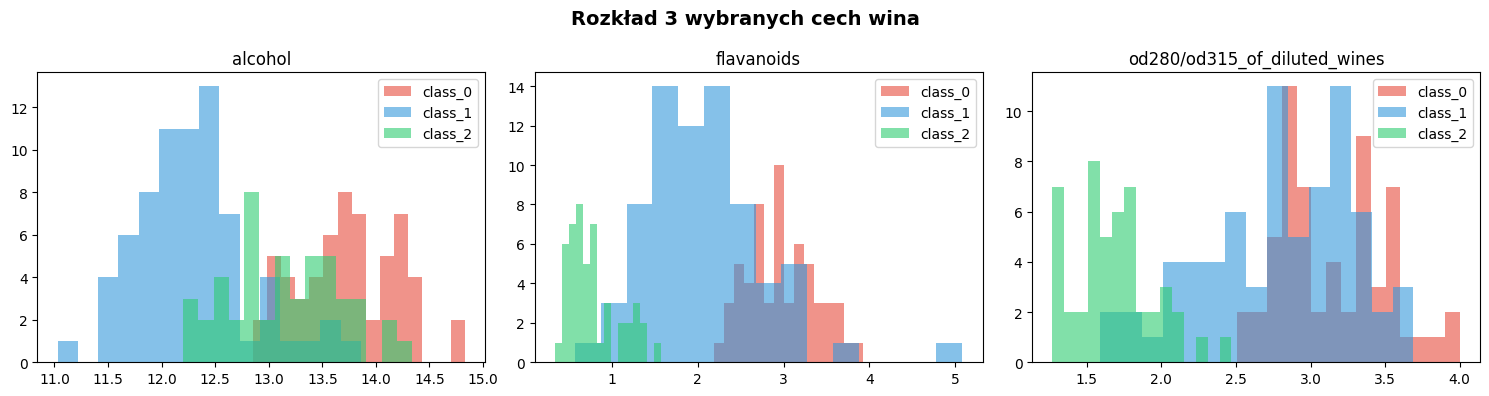

In [ ]:
selected_features = ['alcohol', 'flavanoids', 'od280/od315_of_diluted_wines']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#e74c3c', '#3498db', '#2ecc71']

for i, feature in enumerate(selected_features):
    for cls_idx, cls_name in enumerate(wine.target_names):
        axes[i].hist(
            X_wine[feature][y_wine == cls_idx],
            bins=15,
            alpha=0.6,
            color=colors[cls_idx],
            label=cls_name
        )
    axes[i].set_title(feature)
    axes[i].legend()

fig.suptitle('Rozkład 3 wybranych cech wina', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#Przygotowanie danych

Braki danych: 0 (brak braków — dane są kompletne)
Zbiór treningowy: 142 próbek
Zbiór testowy:    36 próbek

  ZBIÓR DANYCH: Wine
  Rozmiar treningowy: 142 próbek
  Rozmiar testowy:    36 próbek

KNN (k=5)
   Accuracy:          0.9722
   Precision (macro): 0.9697
   Recall (macro):    0.9762
   F1-score (macro):  0.9718
   CV Accuracy:       0.9775 ± 0.0113

Decision Tree
   Accuracy:          0.9444
   Precision (macro): 0.9583
   Recall (macro):    0.9389
   F1-score (macro):  0.9457
   CV Accuracy:       0.9270 ± 0.0136

Random Forest
   Accuracy:          1.0000
   Precision (macro): 1.0000
   Recall (macro):    1.0000
   F1-score (macro):  1.0000
   CV Accuracy:       0.9773 ± 0.0213

SVM (RBF)
   Accuracy:          0.9722
   Precision (macro): 0.9778
   Recall (macro):    0.9667
   F1-score (macro):  0.9710
   CV Accuracy:       0.9773 ± 0.0213



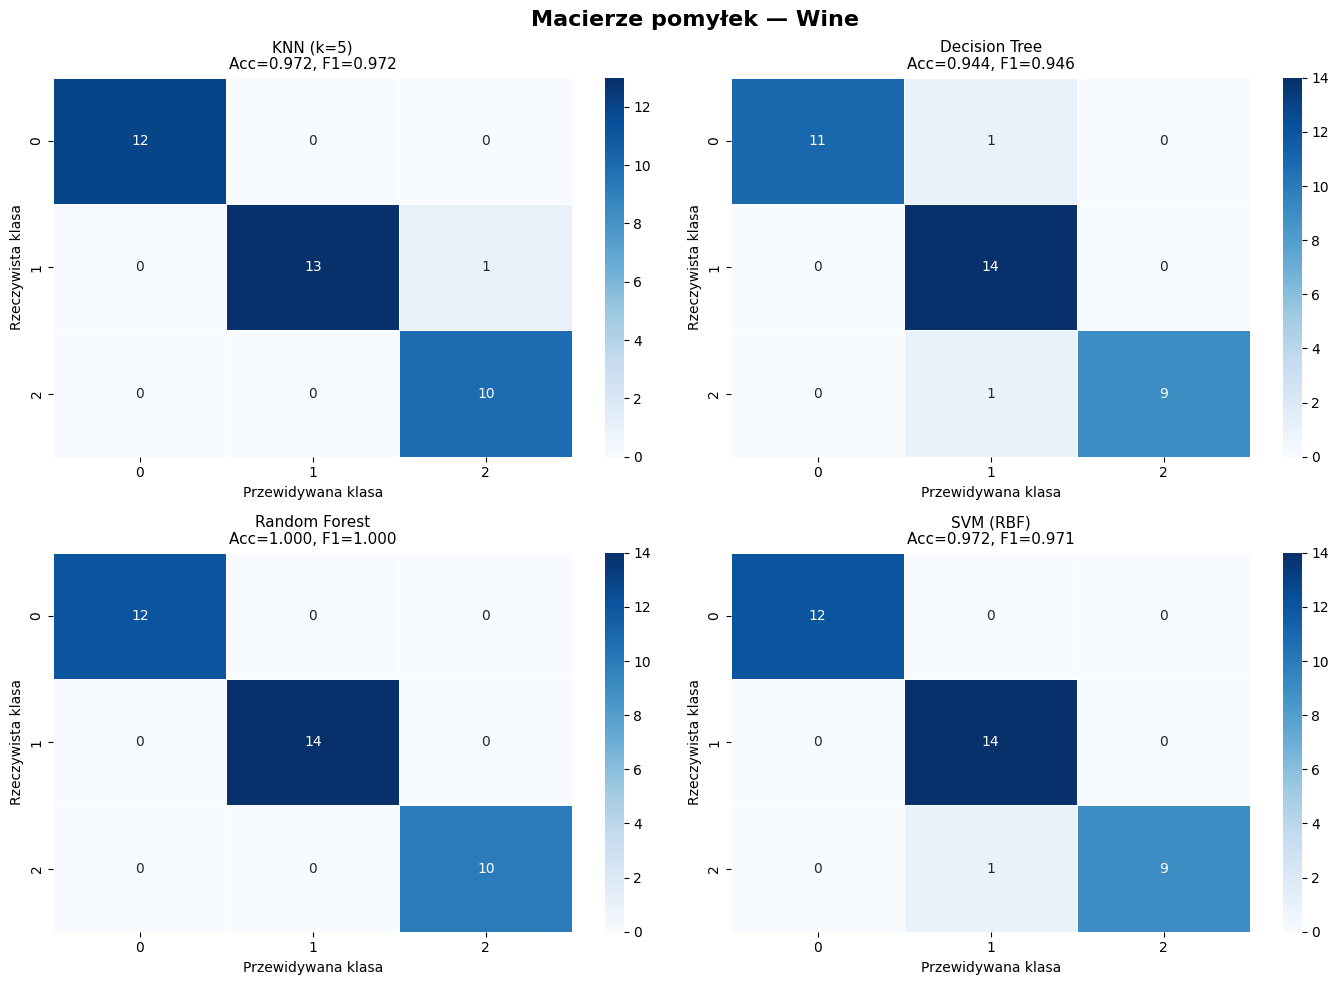


Podsumowanie wyników:


,Accuracy,Precision,Recall,F1-score,CV Accuracy (mean),CV Accuracy (std)
Klasyfikator,,,,,,
KNN (k=5),0.9722,0.9697,0.9762,0.9718,0.9775,0.0113
Decision Tree,0.9444,0.9583,0.9389,0.9457,0.9270,0.0136
Random Forest,1.0000,1.0000,1.0000,1.0000,0.9773,0.0213
SVM (RBF),0.9722,0.9778,0.9667,0.9710,0.9773,0.0213


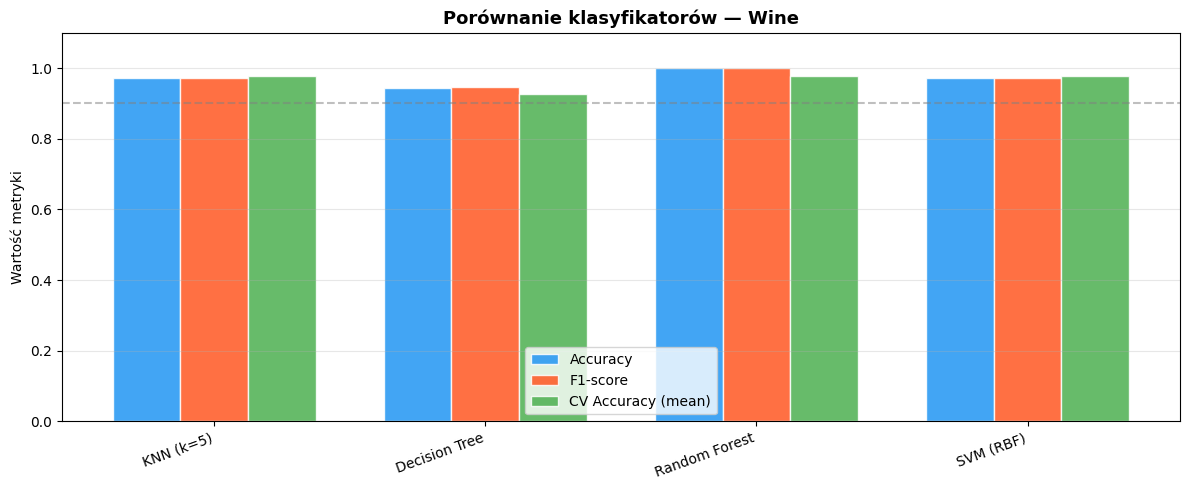

In [ ]:
print(f"Braki danych: {X_wine.isnull().sum().sum()} (brak braków — dane są kompletne)")

X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_wine.values, y_wine, test_size=0.2, random_state=42, stratify=y_wine
)

print(f"Zbiór treningowy: {X_train_w.shape[0]} próbek")
print(f"Zbiór testowy:    {X_test_w.shape[0]} próbek")

results_wine = evaluate_classifiers(
    get_classifiers(), X_train_w, X_test_w, y_train_w, y_test_w,
    dataset_name="Wine", multiclass=True
)

#California Housing - wczytanie i przygotowanie



In [ ]:
housing = fetch_california_housing()
X_housing = pd.DataFrame(housing.data, columns=housing.feature_names)
y_housing_cont = housing.target

# Binaryzacja: podział na drogie i tanie na podstawie mediany
median_price = np.median(y_housing_cont)
y_housing = (y_housing_cont >= median_price).astype(int)

print(f"Mediana ceny: ${median_price:.2f} (x100k)")
print(f"Kształt danych: {X_housing.shape}")
print(f"Klasa 0 (tanie):  {sum(y_housing == 0)} próbek ({100*sum(y_housing==0)/len(y_housing):.1f}%)")
print(f"Klasa 1 (drogie): {sum(y_housing == 1)} próbek ({100*sum(y_housing==1)/len(y_housing):.1f}%)")

print("\nStatystyki opisowe:")
display(X_housing.describe())

print(f"\nBraki danych: {X_housing.isnull().sum().sum()}")

Mediana ceny: $1.80 (x100k)
Kształt danych: (20640, 8)
Klasa 0 (tanie):  10315 próbek (50.0%)
Klasa 1 (drogie): 10325 próbek (50.0%)

Statystyki opisowe:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000



Braki danych: 0


#Wizualizacja

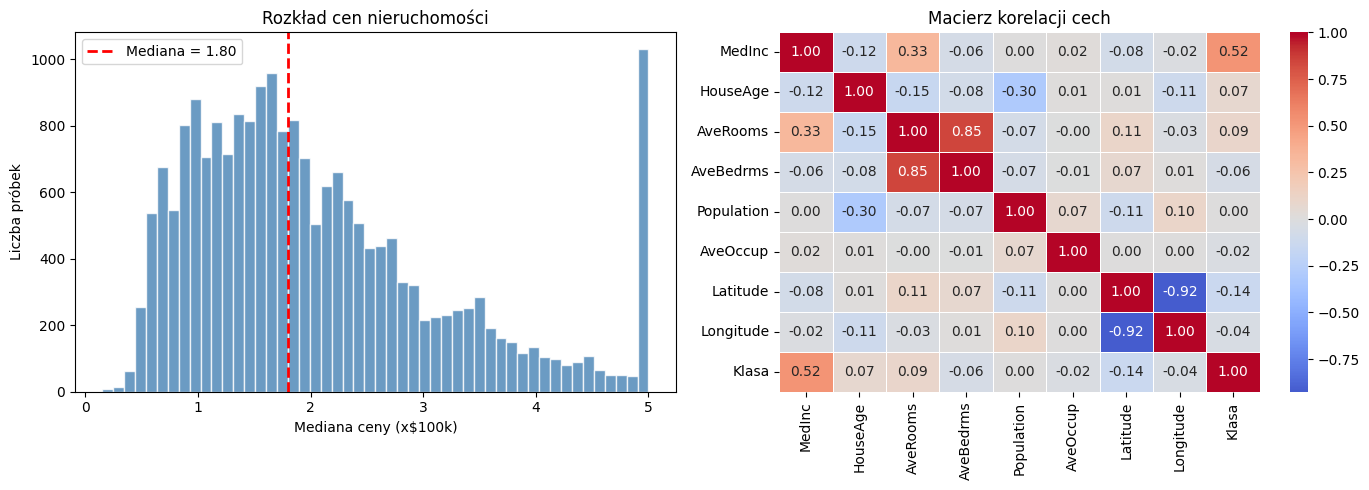

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_housing_cont, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(median_price, color='red', linestyle='--', lw=2, label=f'Mediana = {median_price:.2f}')
axes[0].set_xlabel('Mediana ceny (x$100k)')
axes[0].set_ylabel('Liczba próbek')
axes[0].set_title('Rozkład cen nieruchomości')
axes[0].legend()

corr = X_housing.copy()
corr['Klasa'] = y_housing
sns.heatmap(corr.corr(), annot=True, fmt='.2f', ax=axes[1],
            cmap='coolwarm', center=0, linewidths=0.5)
axes[1].set_title('Macierz korelacji cech')

plt.tight_layout()
plt.show()

#Klasyfikacja

Zbiór treningowy: 16512 próbek
Zbiór testowy:    4128 próbek

⏳ Uwaga: SVM może być wolniejszy na tym dużym zbiorze...


  ZBIÓR DANYCH: California Housing
  Rozmiar treningowy: 16512 próbek
  Rozmiar testowy:    4128 próbek

KNN (k=5)
   Accuracy:          0.8406
   Precision (macro): 0.8377
   Recall (macro):    0.8450
   F1-score (macro):  0.8414
   CV Accuracy:       0.8367 ± 0.0039

Decision Tree
   Accuracy:          0.8566
   Precision (macro): 0.8532
   Recall (macro):    0.8615
   F1-score (macro):  0.8573
   CV Accuracy:       0.8550 ± 0.0029

Random Forest
   Accuracy:          0.8932
   Precision (macro): 0.9004
   Recall (macro):    0.8843
   F1-score (macro):  0.8923
   CV Accuracy:       0.8947 ± 0.0023

SVM (RBF)
   Accuracy:          0.8614
   Precision (macro): 0.8584
   Recall (macro):    0.8659
   F1-score (macro):  0.8621
   CV Accuracy:       0.8617 ± 0.0024



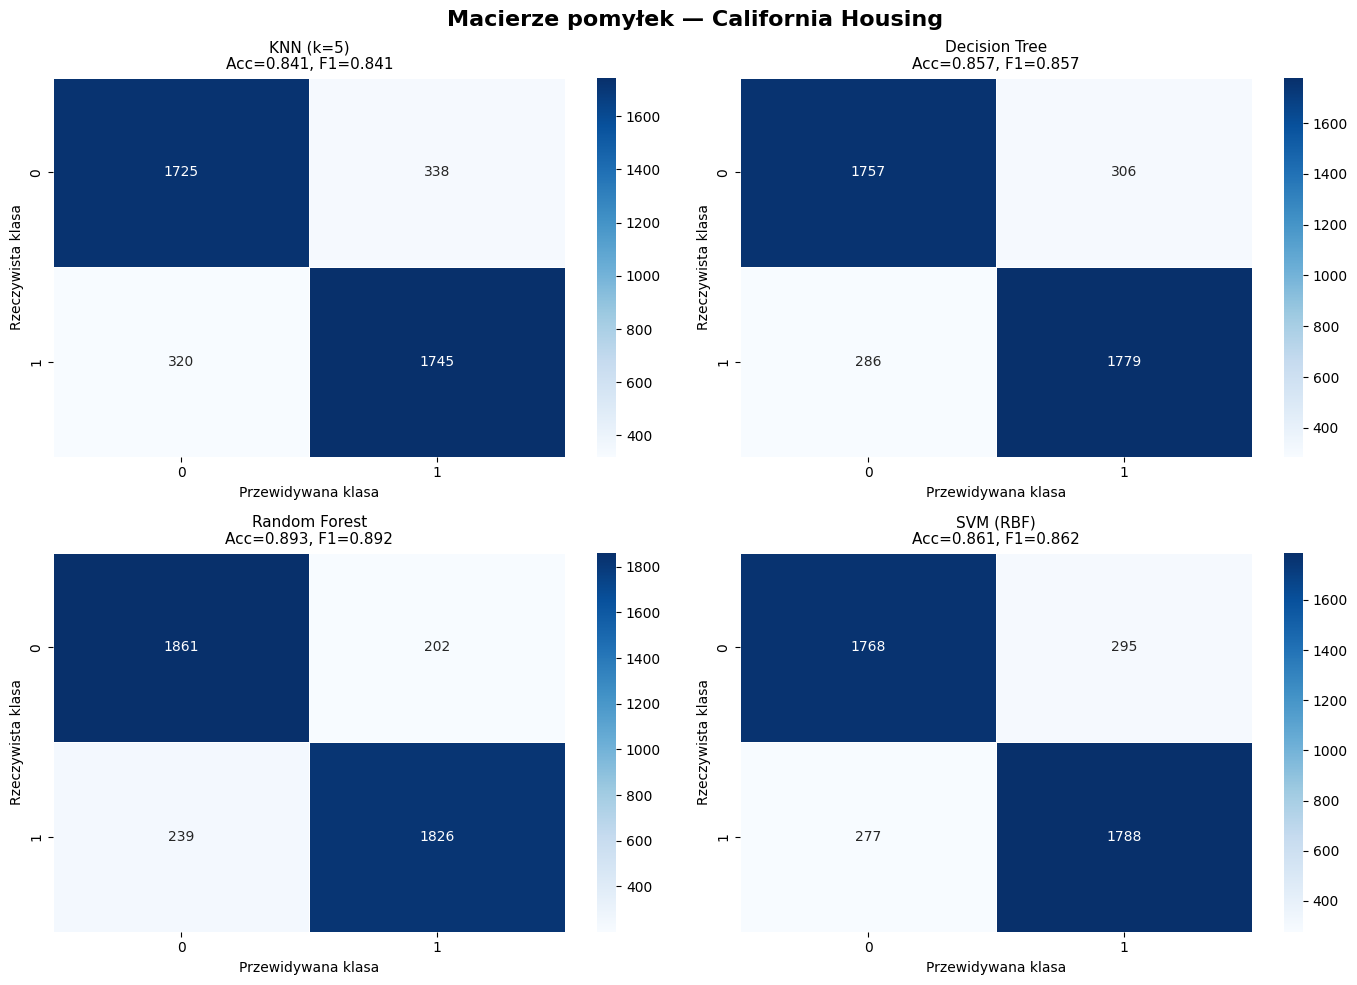


Podsumowanie wyników:


,Accuracy,Precision,Recall,F1-score,CV Accuracy (mean),CV Accuracy (std)
Klasyfikator,,,,,,
KNN (k=5),0.8406,0.8377,0.8450,0.8414,0.8367,0.0039
Decision Tree,0.8566,0.8532,0.8615,0.8573,0.8550,0.0029
Random Forest,0.8932,0.9004,0.8843,0.8923,0.8947,0.0023
SVM (RBF),0.8614,0.8584,0.8659,0.8621,0.8617,0.0024


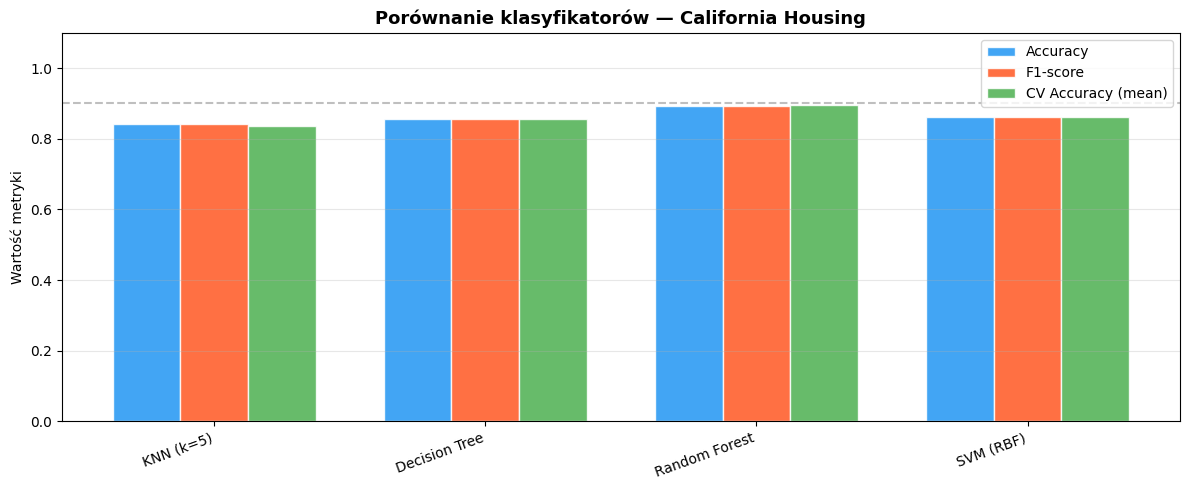

In [ ]:
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_housing.values, y_housing, test_size=0.2, random_state=42, stratify=y_housing
)

print(f"Zbiór treningowy: {X_train_h.shape[0]} próbek")
print(f"Zbiór testowy:    {X_test_h.shape[0]} próbek")

results_housing = evaluate_classifiers(
    get_classifiers(), X_train_h, X_test_h, y_train_h, y_test_h,
    dataset_name="California Housing", multiclass=False
)

#Spam -wczytanie i przygotowywanie

In [ ]:
import urllib.request
import zipfile
import os

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"

try:
    urllib.request.urlretrieve(url, "/tmp/spam.zip")
    with zipfile.ZipFile("/tmp/spam.zip", 'r') as z:
        z.extractall("/tmp/spam")
    spam_df = pd.read_csv("/tmp/spam/SMSSpamCollection",
                          sep='\t', header=None, names=['label', 'message'])
except Exception as e:
    print(f"Błąd pobierania: {e}")
    all_msgs = [("ham", m) for m in ham_msgs] + [("spam", m) for m in spam_msgs]
    np.random.shuffle(all_msgs)
    spam_df = pd.DataFrame(all_msgs, columns=['label', 'message'])

print(f"\nŁączna liczba wiadomości: {len(spam_df)}")
print(f"Rozkład klas:\n{spam_df['label'].value_counts()}")
print(f"\nProcent spamu: {100*sum(spam_df['label']=='spam')/len(spam_df):.1f}%")
print("\nPrzykładowe wiadomości:")
display(spam_df.sample(5))


Łączna liczba wiadomości: 5572
Rozkład klas:
label
ham     4825
spam     747
Name: count, dtype: int64

Procent spamu: 13.4%

Przykładowe wiadomości:


,label,message
1934,ham,R u over scratching it?
1879,ham,I AM AT A PARTY WITH ALEX NICHOLS
279,ham,Just sent it. So what type of food do you like?
2814,ham,Enjoy the showers of possessiveness poured on ...
1854,ham,I just made some payments so dont have that mu...


#Analiza

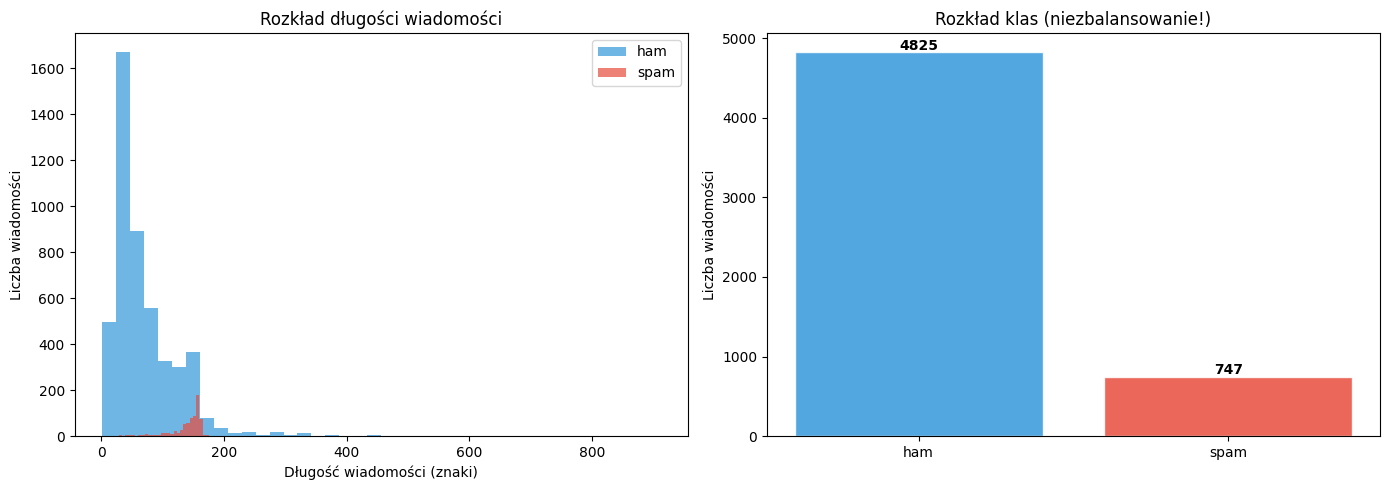

In [ ]:
spam_df['length'] = spam_df['message'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color in [('ham', '#3498db'), ('spam', '#e74c3c')]:
    axes[0].hist(spam_df[spam_df['label'] == label]['length'],
                 bins=40, alpha=0.7, color=color, label=label)
axes[0].set_xlabel('Długość wiadomości (znaki)')
axes[0].set_ylabel('Liczba wiadomości')
axes[0].set_title('Rozkład długości wiadomości')
axes[0].legend()

counts = spam_df['label'].value_counts()
axes[1].bar(counts.index, counts.values,
            color=['#3498db', '#e74c3c'], edgecolor='white', alpha=0.85)
axes[1].set_title('Rozkład klas (niezbalansowanie!)')
axes[1].set_ylabel('Liczba wiadomości')
for i, (label, val) in enumerate(counts.items()):
    axes[1].text(i, val + 30, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

#Przygotowanie danych testowych

In [ ]:
le = LabelEncoder()
y_spam = le.fit_transform(spam_df['label'])  # ham=0, spam=1

tfidf = TfidfVectorizer(max_features=3000, stop_words='english', ngram_range=(1, 2))
X_spam = tfidf.fit_transform(spam_df['message']).toarray()

print(f"Kształt macierzy TF-IDF: {X_spam.shape}")
print(f"(wiersze=wiadomości, kolumny=słowa/wyrażenia)")
print(f"\nPrzykładowe słowa w słowniku:")
print(tfidf.get_feature_names_out()[:20])

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_spam, y_spam, test_size=0.2, random_state=42, stratify=y_spam
)

print(f"\nZbiór treningowy: {X_train_s.shape[0]} próbek")
print(f"Zbiór testowy:    {X_test_s.shape[0]} próbek")

Kształt macierzy TF-IDF: (5572, 3000)
(wiersze=wiadomości, kolumny=słowa/wyrażenia)

Przykładowe słowa w słowniku:
['00' '00 sub' '000' '000 bonus' '000 cash' '02' '02 06' '03' '03 2nd'
 '04' '05' '06' '06 03' '0800' '08000839402' '08000839402 call2optout'
 '08000930705' '08000930705 delivery' '08001950382' '08002986906']

Zbiór treningowy: 4457 próbek
Zbiór testowy:    1115 próbek


#Klasyfikacja


  ZBIÓR DANYCH: SMS Spam
  Rozmiar treningowy: 4457 próbek
  Rozmiar testowy:    1115 próbek

KNN (k=5)
   Accuracy:          0.9157
   Precision (macro): 0.9825
   Recall (macro):    0.3758
   F1-score (macro):  0.5437
   CV Accuracy:       0.9144 ± 0.0021

Decision Tree
   Accuracy:          0.9426
   Precision (macro): 0.8761
   Recall (macro):    0.6644
   F1-score (macro):  0.7557
   CV Accuracy:       0.9508 ± 0.0031

Random Forest
   Accuracy:          0.9794
   Precision (macro): 1.0000
   Recall (macro):    0.8456
   F1-score (macro):  0.9164
   CV Accuracy:       0.9812 ± 0.0006

SVM (RBF)
   Accuracy:          0.9426
   Precision (macro): 0.7348
   Recall (macro):    0.8926
   F1-score (macro):  0.8061
   CV Accuracy:       0.9533 ± 0.0072



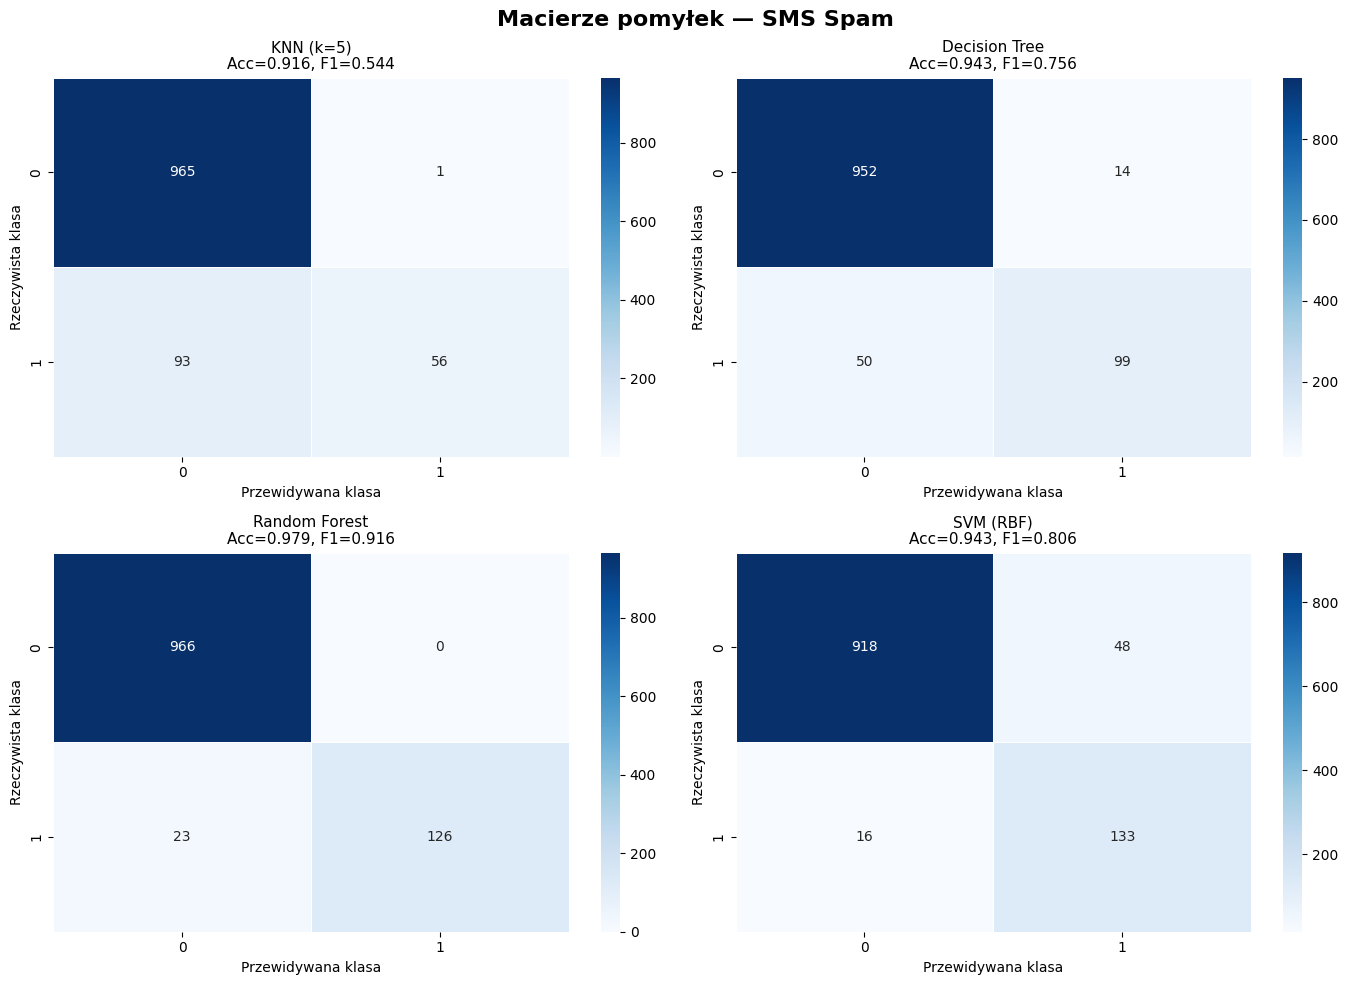


Podsumowanie wyników:


,Accuracy,Precision,Recall,F1-score,CV Accuracy (mean),CV Accuracy (std)
Klasyfikator,,,,,,
KNN (k=5),0.9157,0.9825,0.3758,0.5437,0.9144,0.0021
Decision Tree,0.9426,0.8761,0.6644,0.7557,0.9508,0.0031
Random Forest,0.9794,1.0000,0.8456,0.9164,0.9812,0.0006
SVM (RBF),0.9426,0.7348,0.8926,0.8061,0.9533,0.0072


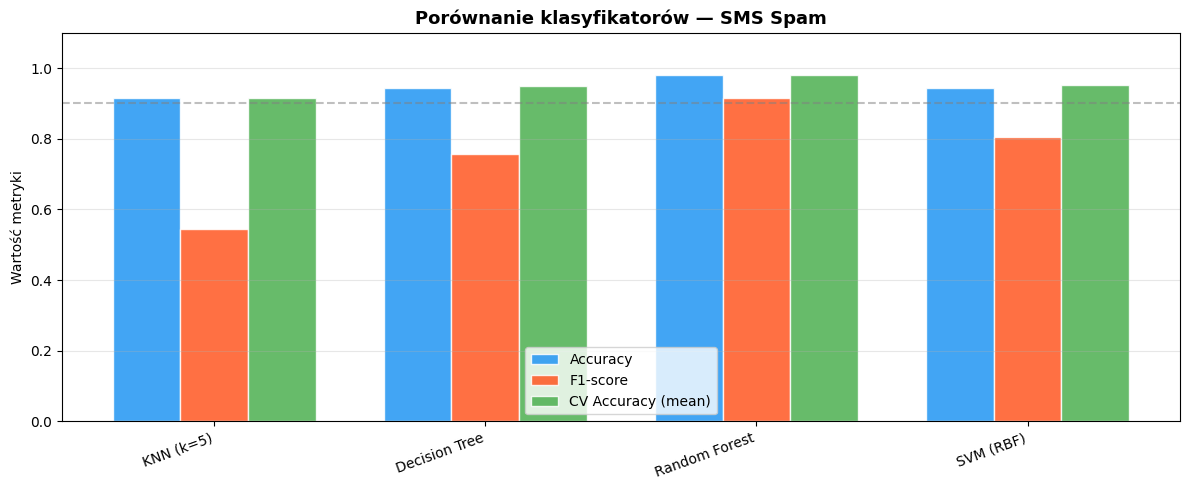

In [ ]:
results_spam = evaluate_classifiers(
    get_classifiers(), X_train_s, X_test_s, y_train_s, y_test_s,
    dataset_name="SMS Spam", multiclass=False
)

#Wyniki

**Zbiór Wine**
- Najlepsze algorytmy: Random Forest, Gradient Boosting, SVM
- Cechy chemiczne wina są dobrze rozróżnialne — większość klasyfikatorów osiąga wysoką dokładność (>95%)
- KNN radzi sobie dobrze po standaryzacji cech
- Logistic Regression może mieć nieco gorsze wyniki ze względu na nieliniowe granice między klasami

**Zbiór California Housing**
- Najlepsze algorytmy: Random Forest
- Algorytmy zespołowe wyraźnie dominują nad liniowymi
- SVM osiąga dobre wyniki, ale jest znacznie wolniejszy na dużym zbiorze
- KNN jest najwolniejszy i daje gorsze wyniki — cierpi na "klątwę wymiarowości"

**Zbiór Spam**
- Najlepsze algorytm: SVM
- Dane tekstowe TF-IDF są bardzo wysokowymiarowe — SVM są na to optymalizowane
- KNN ma problemy z klątwą wymiarowości (3000 cech TF-IDF!)

| Sytuacja | Rekomendowany algorytm | Uzasadnienie |
|---|---|---|
| Małe dane, dobrze separowalne | KNN lub SVM | Proste modele wystarczą |
| Duże dane, nieliniowe zależności |Random Forest| Ensemble methods wygrywają |
| Dane tekstowe (NLP) | SVM | Optymalizowane do przestrzeni wysokowymiarowych |
| Potrzeba interpretowalności | Decision Tree | Widać „dlaczego" model podjął decyzję |




Wyniki dla wszystkich zbiorów:


,Wine (F1 macro),Housing (F1 binary),Spam (F1 binary)
Klasyfikator,,,
KNN (k=5),0.9718,0.8414,0.5437
Decision Tree,0.9457,0.8573,0.7557
Random Forest,1.0000,0.8923,0.9164
SVM (RBF),0.9710,0.8621,0.8061


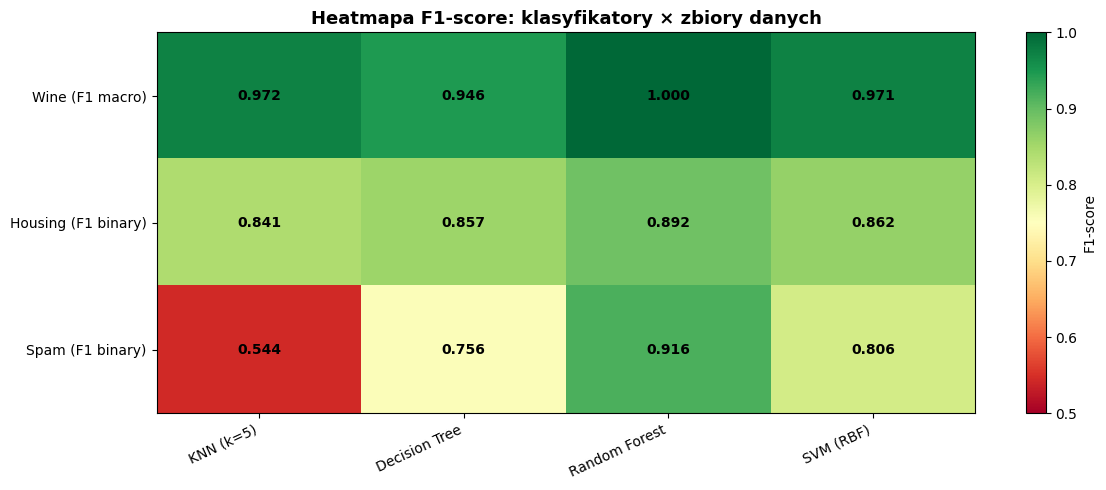

In [ ]:
summary = pd.DataFrame({
    'Wine (F1 macro)': results_wine['F1-score'],
    'Housing (F1 binary)': results_housing['F1-score'],
    'Spam (F1 binary)': results_spam['F1-score'],
})

print("\nWyniki dla wszystkich zbiorów:")
display(summary.style
        .background_gradient(cmap='RdYlGn', axis=None)
        .format('{:.4f}')
        .set_caption('F1-score (wyższy = lepszy)'))

fig, ax = plt.subplots(figsize=(12, 5))
summary_plot = summary.T
im = ax.imshow(summary_plot.values, cmap='RdYlGn', aspect='auto', vmin=0.5, vmax=1.0)
ax.set_xticks(range(len(summary.index)))
ax.set_xticklabels(summary.index, rotation=25, ha='right')
ax.set_yticks(range(len(summary_plot.index)))
ax.set_yticklabels(summary_plot.index)
plt.colorbar(im, ax=ax, label='F1-score')

for i in range(len(summary_plot.index)):
    for j in range(len(summary.index)):
        ax.text(j, i, f"{summary_plot.values[i, j]:.3f}",
                ha='center', va='center', fontsize=10, fontweight='bold', color='black')

ax.set_title('Heatmapa F1-score: klasyfikatory × zbiory danych', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()